In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
import pandas as pd

df = pd.read_csv("../data/gurugram_real_estate_cleaned (1).csv")

df.head()

,Price,Status,Area,Rate_per_sqft,Property_Type,Locality,Builder_Name,RERA_Approval,BHK_Count,Socity,Company_Name,Flat_Type,Calculated_Rate_per_sqft,Price_Lakh
0,10700000.0,Under Construction,1138,9450,2 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,home,Approved by RERA,2.0,M3M Antalya Hills Phase I,M3M,Apartment,9402.46,107.0
1,14400000.0,Under Construction,1528,9450,3 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,Property In Gurgaon,Approved by RERA,3.0,M3M Antalya Hills Phase I,M3M,Apartment,9424.08,144.0
2,10700000.0,Under Construction,1138,9450,2 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,properties for sale in Gurgaon,Approved by RERA,2.0,M3M Antalya Hills Phase I,M3M,Apartment,9402.46,107.0
3,40000000.0,Ready to move,4500,8888,4 BHK Independent Floor,Sector 57,MM India Pvt Ltd,Not approved by RERA,4.0,Outside Socity,Outside,Plot,8888.89,400.0
4,24000000.0,Under Construction,1800,13333,3 BHK Independent Floor in Anant Raj Estate Plots,Sector 63,MM India Pvt Ltd,Approved by RERA,3.0,Anant Raj Estate Plots,Anant,Floor,13333.33,240.0


In [3]:
df.shape

(14223, 14)

In [4]:
df.columns.tolist()

['Price',
 'Status',
 'Area',
 'Rate_per_sqft',
 'Property_Type',
 'Locality',
 'Builder_Name',
 'RERA_Approval',
 'BHK_Count',
 'Socity',
 'Company_Name',
 'Flat_Type',
 'Calculated_Rate_per_sqft',
 'Price_Lakh']

In [5]:
df.dtypes

Price                       float64
Status                          str
Area                          int64
Rate_per_sqft                 int64
Property_Type                   str
Locality                        str
Builder_Name                    str
RERA_Approval                   str
BHK_Count                   float64
Socity                          str
Company_Name                    str
Flat_Type                       str
Calculated_Rate_per_sqft    float64
Price_Lakh                  float64
dtype: object

In [6]:
df.isnull().sum()

Price                         0
Status                        0
Area                          0
Rate_per_sqft                 0
Property_Type                 0
Locality                      0
Builder_Name                  0
RERA_Approval                 0
BHK_Count                   999
Socity                        0
Company_Name                  0
Flat_Type                     0
Calculated_Rate_per_sqft      0
Price_Lakh                    0
dtype: int64

In [7]:
df["BHK_Count"] = df["BHK_Count"].replace(999, np.nan)

In [8]:
df["BHK_Count"].isnull().sum()

np.int64(999)

In [9]:
df[["Price", "Area", "Rate_per_sqft", "Price_Lakh"]].describe()

,Price,Area,Rate_per_sqft,Price_Lakh
count,1.422300e+04,14223.000000,14223.000000,14223.000000
mean,3.995377e+07,2621.755959,15296.143992,399.537664
std,5.755291e+07,11125.298077,18761.002333,575.529080
min,9.500000e+04,60.000000,100.000000,0.950000
25%,1.410000e+07,1424.000000,8368.000000,141.000000
50%,2.620000e+07,2015.000000,12380.000000,262.000000
75%,4.550000e+07,2840.500000,18500.000000,455.000000
max,1.226300e+09,958320.000000,310000.000000,12263.000000


In [10]:
df.nlargest(10, "Area")[[
    "Price",
    "Area",
    "Rate_per_sqft",
    "Property_Type",
    "Locality",
    "BHK_Count"
]]

,Price,Area,Rate_per_sqft,Property_Type,Locality,BHK_Count
12236,1.197000e+08,958320,125,Residential Plot,37D Dwarka Exp Gurgaon,NaN
12628,7.500000e+08,653400,1147,Residential Plot in Baliawas farms,Baliawas,NaN
12199,5.000000e+08,435600,1147,Residential Plot,Baliawas,NaN
12312,5.000000e+08,435600,1147,Residential Plot,Baliawas,NaN
7981,9.000000e+07,87300,1030,Residential Plot,Sector 75,NaN
4179,1.100000e+08,40500,2716,Residential Plot in Suncity Sun City,Sector 54,NaN
2212,1.226300e+09,16500,74323,6 BHK Apartment in DLF Camellias,Sector 42,6.0
6510,1.226300e+09,16500,74323,6 BHK Apartment in DLF Camellias,Sector 42,6.0
2214,1.189100e+09,16000,74324,6 BHK Apartment in DLF Camellias,Sector 42,6.0
1445,3.057000e+08,15500,19725,5 BHK Apartment in Ambience Caitriona,Sector 24,5.0


In [11]:
top_localities = df["Locality"].value_counts().head(10)

top_localities

Locality
Sector 65     857
Sector 79     576
Sector 63     498
Sector 67     486
Sector 113    454
Sector 108    439
Sector 102    427
Sector 37D    421
Sector 106    418
Sector 36A    396
Name: count, dtype: int64

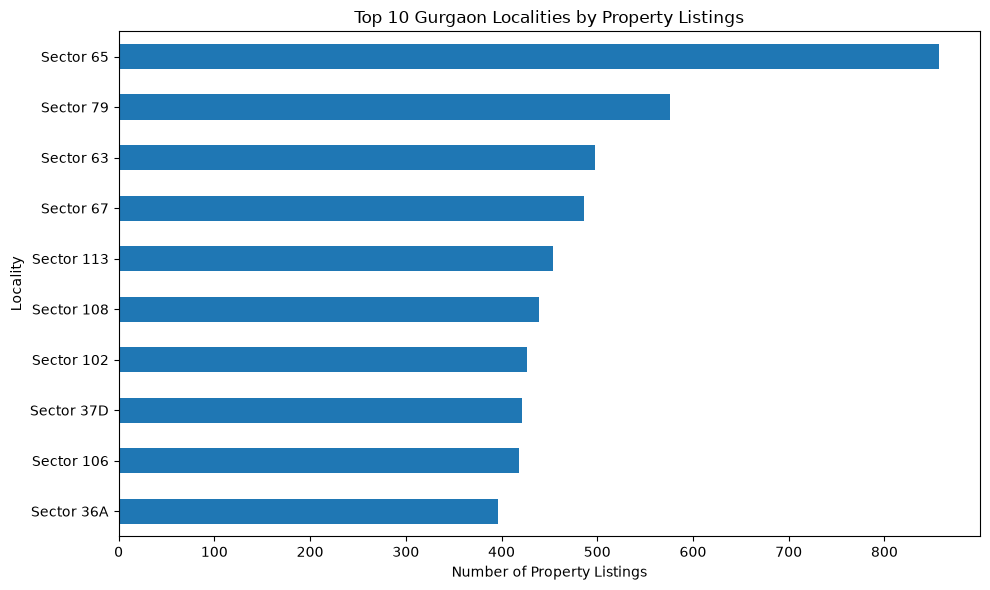

In [12]:
plt.figure(figsize=(10, 6))

top_localities.sort_values().plot(kind="barh")

plt.title("Top 10 Gurgaon Localities by Property Listings")
plt.xlabel("Number of Property Listings")
plt.ylabel("Locality")

plt.tight_layout()
plt.show()

In [13]:
locality_avg_price = (
    df.groupby("Locality")["Price_Lakh"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

locality_avg_price

Locality
Baliawas                  5833.333333
Sector 42                 5023.611667
Beverly Park              1953.666667
Aralias Drive             1636.583333
Golf Course Road          1475.139130
Sector 73                 1281.941176
37D Dwarka Exp Gurgaon    1197.000000
Ambience Island           1100.000000
Sector 24                 1086.422535
Sector 113                 980.810573
Name: Price_Lakh, dtype: float64

In [14]:
residential_df = df[df["Flat_Type"].isin(["Apartment", "Floor"])]

locality_residential_price = (
    residential_df.groupby("Locality")["Price_Lakh"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

locality_residential_price

Locality
Sector 42           5118.391379
Beverly Park        1503.500000
Aralias Drive       1444.375000
Sector 24           1150.400000
Ambience Island     1100.000000
Sector 113           989.114094
Golf Course Road     958.500000
Sector 53            893.679389
Sector 54            886.560440
Gwal Pahari          866.250000
Name: Price_Lakh, dtype: float64

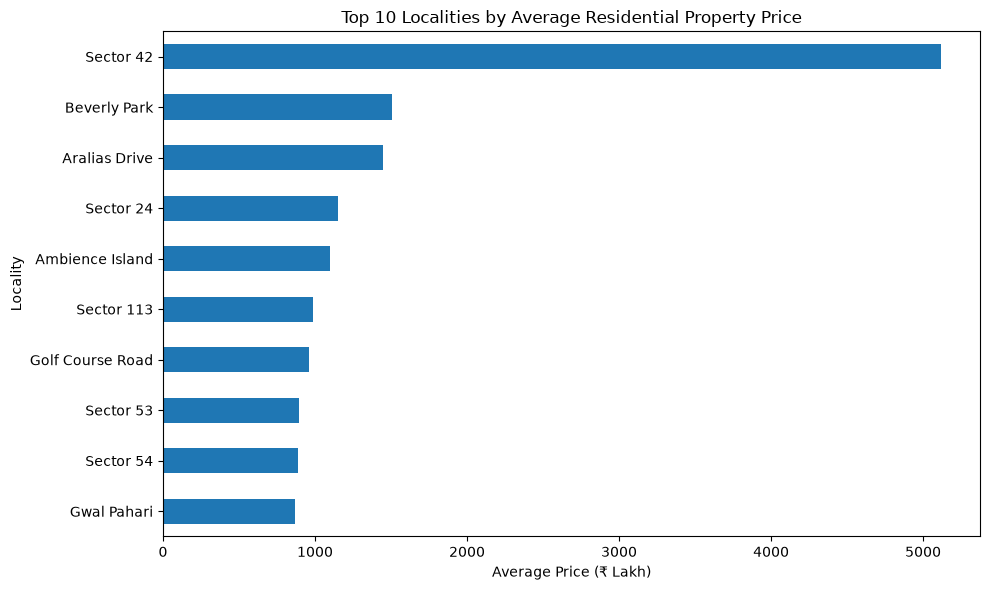

In [15]:
plt.figure(figsize=(10, 6))

locality_residential_price.sort_values().plot(kind="barh")

plt.title("Top 10 Localities by Average Residential Property Price")
plt.xlabel("Average Price (₹ Lakh)")
plt.ylabel("Locality")

plt.tight_layout()
plt.show()

In [16]:
bhk_avg_price = (
    residential_df.dropna(subset=["BHK_Count"])
    .groupby("BHK_Count")["Price_Lakh"]
    .mean()
    .sort_index()
)

bhk_avg_price

BHK_Count
1.0       72.432438
2.0      161.119773
3.0      319.804310
4.0      593.460018
5.0     1314.672249
6.0     2985.846154
7.0     2674.285714
9.0      250.000000
10.0    2000.000000
Name: Price_Lakh, dtype: float64

In [17]:
bhk_avg_price_normal = bhk_avg_price[bhk_avg_price.index <= 5]

bhk_avg_price_normal

BHK_Count
1.0      72.432438
2.0     161.119773
3.0     319.804310
4.0     593.460018
5.0    1314.672249
Name: Price_Lakh, dtype: float64

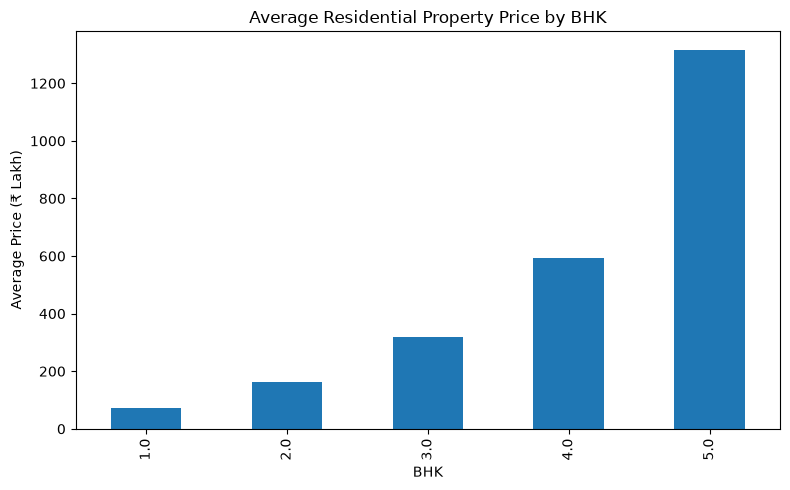

In [18]:
plt.figure(figsize=(8, 5))

bhk_avg_price_normal.plot(kind="bar")

plt.title("Average Residential Property Price by BHK")
plt.xlabel("BHK")
plt.ylabel("Average Price (₹ Lakh)")

plt.tight_layout()
plt.show()

In [19]:
property_type_count = df["Flat_Type"].value_counts()

property_type_count

Flat_Type
Apartment    10894
Plot          2166
Floor          881
Villa          205
House           45
Penthouse       32
Name: count, dtype: int64

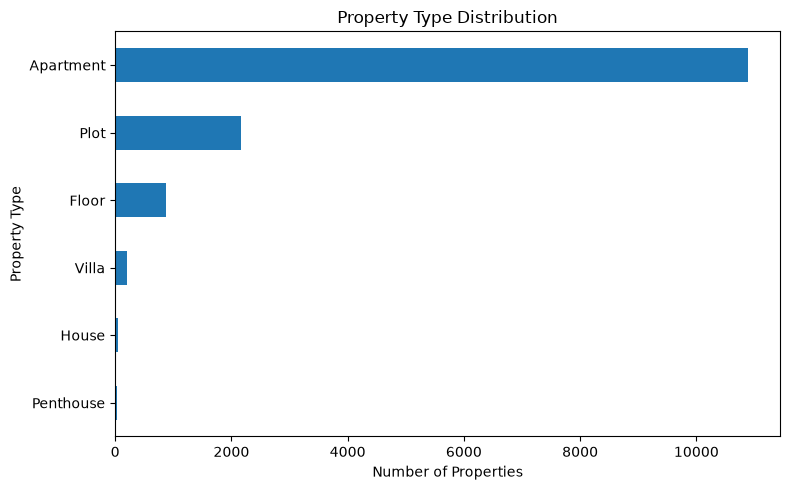

In [20]:
plt.figure(figsize=(8, 5))

property_type_count.sort_values().plot(kind="barh")

plt.title("Property Type Distribution")
plt.xlabel("Number of Properties")
plt.ylabel("Property Type")

plt.tight_layout()
plt.show()

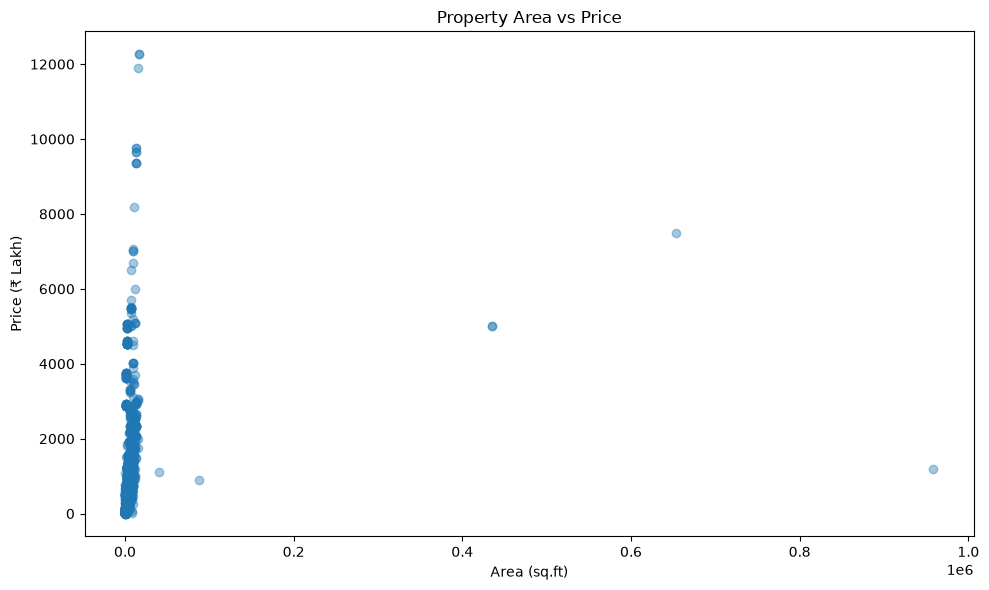

In [21]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Area"],
    df["Price_Lakh"],
    alpha=0.4
)

plt.title("Property Area vs Price")
plt.xlabel("Area (sq.ft)")
plt.ylabel("Price (₹ Lakh)")

plt.tight_layout()
plt.show()

In [22]:
df[["Area", "Price_Lakh"]].corr()

,Area,Price_Lakh
Area,1.000000,0.197411
Price_Lakh,0.197411,1.000000


In [23]:
residential_df[["Area", "Price_Lakh"]].corr()

,Area,Price_Lakh
Area,1.000000,0.625303
Price_Lakh,0.625303,1.000000


In [24]:
locality_rate = (
    residential_df.groupby("Locality")["Rate_per_sqft"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

locality_rate

Locality
Sector 42        56927.137931
Sector 113       52914.366890
Sector 15        31650.000000
Sector 53        29558.061069
Sector 80        29115.250000
Sector 54        28474.948718
Beverly Park     25089.500000
Aralias Drive    23284.500000
Sector 49        23153.046875
Sector 58        22372.184783
Name: Rate_per_sqft, dtype: float64

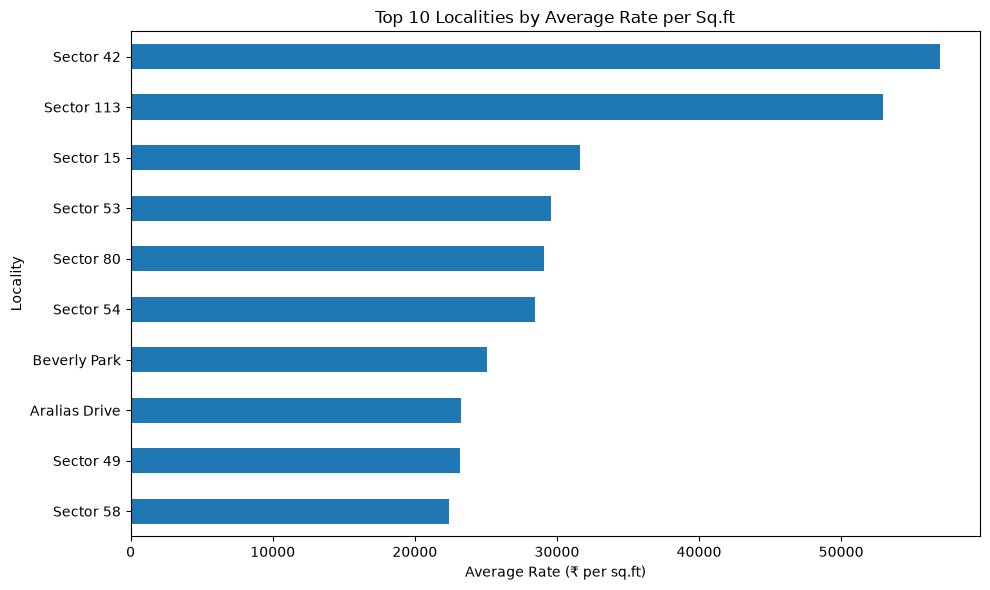

In [25]:
plt.figure(figsize=(10, 6))

locality_rate.sort_values().plot(kind="barh")

plt.title("Top 10 Localities by Average Rate per Sq.ft")
plt.xlabel("Average Rate (₹ per sq.ft)")
plt.ylabel("Locality")

plt.tight_layout()
plt.show()

In [26]:
status_count = df["Status"].value_counts()

status_count

Status
Ready to move         7823
Under Construction    5269
New                    834
Resale                 297
Name: count, dtype: int64

In [27]:
status_percentage = (
    df["Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

status_percentage

Status
Ready to move         55.00
Under Construction    37.05
New                    5.86
Resale                 2.09
Name: proportion, dtype: float64

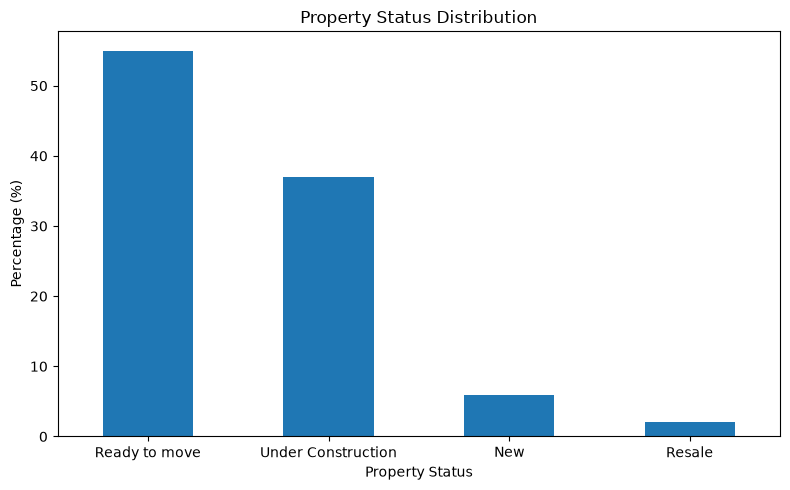

In [28]:
plt.figure(figsize=(8, 5))

status_percentage.plot(
    kind="bar",
    title="Property Status Distribution"
)

plt.xlabel("Property Status")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [29]:
builder_count = (
    df["Builder_Name"]
    .value_counts()
    .head(10)
)

builder_count

Builder_Name
properties for sale in Gurgaon    818
Property In Gurgaon               810
home                              803
Proptiger                         734
Sharma Prop                       490
WADHWA REALTORS                   299
Search My Property                242
SBL                               198
The Assetree                      165
Multi Home Realtors               162
Name: count, dtype: int64

In [30]:
df["Builder_Name"].value_counts().head(30)

Builder_Name
properties for sale in Gurgaon       818
Property In Gurgaon                  810
home                                 803
Proptiger                            734
Sharma Prop                          490
WADHWA REALTORS                      299
Search My Property                   242
SBL                                  198
The Assetree                         165
Multi Home Realtors                  162
INFRAMANTRA INDIA PRIVATE LIMITED    154
Provident Capital                    151
Property Master                      134
Onkar real estate solutions          129
ETHOS PRO REALTORS                   123
Thirty Three Estates Developers      121
seller                               113
Surendra Realtors                    113
HOMZ SOLUTIONS                       110
Individual Agent                     109
Gupta Realtors                       100
S S Properties                       100
Yasir                                 98
Make My asset                         97
Emp

In [31]:
builder_keywords = [
    "developer",
    "developers",
    "realty",
    "real estate",
    "infra",
    "properties",
    "homes",
    "builders",
    "construction",
    "limited",
    "ltd",
    "capital"
]

builder_df = df[
    df["Builder_Name"]
    .str.lower()
    .str.contains("|".join(builder_keywords), na=False)
]

builder_count_clean = (
    builder_df["Builder_Name"]
    .value_counts()
    .head(10)
)

builder_count_clean

Builder_Name
properties for sale in Gurgaon       818
INFRAMANTRA INDIA PRIVATE LIMITED    154
Provident Capital                    151
Onkar real estate solutions          129
Thirty Three Estates Developers      121
S S Properties                       100
Gravity Advisors Pvt Ltd              93
MODCO REAL ESTATE PRIVATE LIMITED     91
Bharat hotels infrastructure          85
Khushi Housing Solutions Pvt Ltd      82
Name: count, dtype: int64

In [32]:
rera_count = df["RERA_Approval"].value_counts()

rera_count

RERA_Approval
Not approved by RERA    8774
Approved by RERA        5449
Name: count, dtype: int64

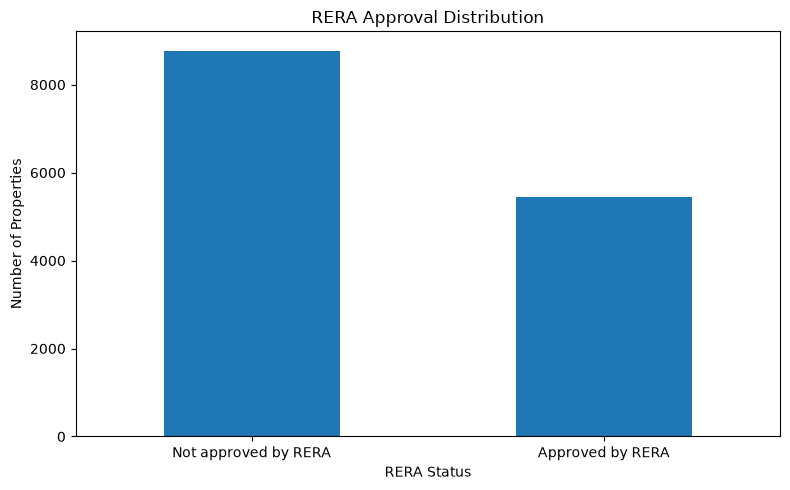

In [33]:
plt.figure(figsize=(8, 5))

rera_count.plot(
    kind="bar",
    title="RERA Approval Distribution"
)

plt.xlabel("RERA Status")
plt.ylabel("Number of Properties")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [34]:
rera_avg_price = (
    df.groupby("RERA_Approval")["Price_Lakh"]
    .mean()
    .sort_values(ascending=False)
)

rera_avg_price

RERA_Approval
Not approved by RERA    407.901518
Approved by RERA        386.070156
Name: Price_Lakh, dtype: float64

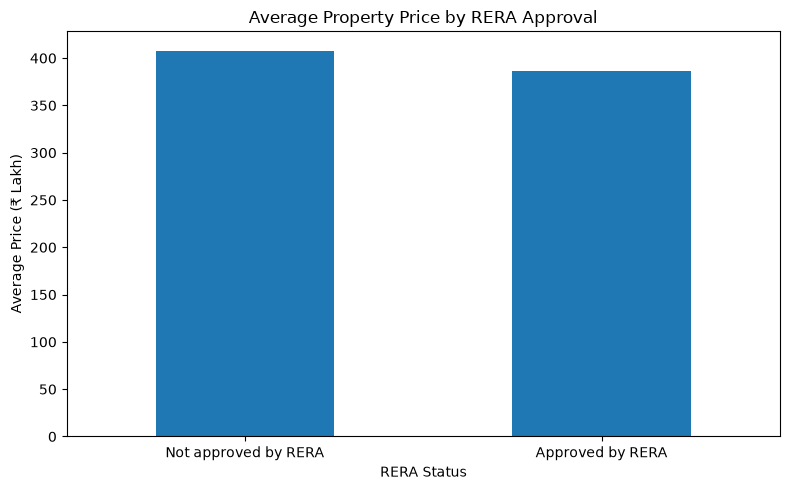

In [35]:
plt.figure(figsize=(8, 5))

rera_avg_price.plot(kind="bar")

plt.title("Average Property Price by RERA Approval")
plt.xlabel("RERA Status")
plt.ylabel("Average Price (₹ Lakh)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()